In [55]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import comb, pi, sqrt

from sklearn import svm
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score,accuracy_score

# these imports are from three_profile.py and four_profile.py files
from four_profile_src.four_profile import four_profile
from four_profile_src.three_profile import three_profile

In [56]:
df_oil_k3 = pd.read_csv('data/Oil Trade k3 graph.csv')

In [57]:
graph_oil_k3 = nx.Graph()
for row in df_oil_k3.itertuples():
    # if row.year == 2020:
    graph_oil_k3.add_edge(row.source, row.target, year=row.year)


## Graph Generation Models: Gnp, ChungLu, PA, Config, Geometric

In [58]:
n = graph_oil_k3.number_of_nodes()
m = graph_oil_k3.number_of_edges()

In [59]:
print(n,m)

237 2534


In [60]:
# gnp generator
p = m / comb(n, 2)
gnp_graphs = []
for i in range(100):
    gnp = nx.gnp_random_graph(n, p, seed=i)
    gnp_graphs.append(gnp)

In [61]:
# ChungLu Generator
degree_distribution = [d for v,d in graph_oil_k3.degree()]
chunglu_graphs = []
for i in range(100):
    g_chunglu = nx.expected_degree_graph(degree_distribution, seed=i, selfloops=False)
    chunglu_graphs.append(g_chunglu)

In [62]:
# PA, preferential attachment
degree_distribution = [d for v,d in graph_oil_k3.degree()]
pa_m = (m - 1) / n # m parameter for PA, 2/n + 2m = 2|E| / n

pa_graphs = []
for i in range(100):
    g_pa = nx.barabasi_albert_graph(n=n, m=int(pa_m), seed=i)
    pa_graphs.append(g_pa)

In [63]:
# Configuration (random graph with same degree distribution)
degree_distribution = [d for v,d in graph_oil_k3.degree()]
config_graphs = []
for i in range(100):
    g_config = nx.configuration_model(degree_distribution, seed=i)
    g_config.remove_edges_from(nx.selfloop_edges(g_config))
    g_config_simple = nx.Graph(g_config)
    config_graphs.append(g_config_simple)

In [64]:
# Geometric Model
r = sqrt((2.0 * m) / (n * (n-1) * pi))
# r = sqrt((2.0 * m) / (n * (n-1) * pi)) * 1.08
# typically, r would be set without 1.08 multiplier, however, since # edges is so large, the radius needs to be rather large
# in the case of large radius, the approximation of r without the 1.08 multipler falls short because the radius
# of the circles can go past the boundary of the unit cube

geometric_graphs = []
for i in range(100):
    g_geometric = nx.random_geometric_graph(n=n, radius=r, seed=i)
    geometric_graphs.append(g_geometric)

## Create Vector Embeddings Using 3 & 4 Profile

In [65]:
x = np.empty([500,15])
x[:] = np.nan

for i in range(100):
    x[i] = np.array(list(four_profile(gnp_graphs[i])) + list(three_profile(gnp_graphs[i])), dtype=np.int64)
    x[i+100] = np.array(list(four_profile(chunglu_graphs[i])) + list(three_profile(chunglu_graphs[i])), dtype=np.int64)
    x[i+200] = np.array(list(four_profile(pa_graphs[i])) + list(three_profile(pa_graphs[i])), dtype=np.int64)
    x[i+300] = np.array(list(four_profile(config_graphs[i])) + list(three_profile(config_graphs[i])), dtype=np.int64)
    x[i+400] = np.array(list(four_profile(geometric_graphs[i])) + list(three_profile(geometric_graphs[i])), dtype=np.int64)

In [66]:
# single dimension y
# labels: 1 is gnp, 2 is chunglu, 3 is pa, 4 is config, 5 is geometric
y = np.empty([500,])
y[0:100] = 1
y[100:200] = 2
y[200:300] = 3
y[300:400] = 4
y[400:500] = 5


## Train models with Kfold gridsearch

In [67]:
kfold = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
graph_embedding = np.array(list(four_profile(graph_oil_k3)) + list(three_profile(graph_oil_k3)), dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=17, stratify=y)

## Use SVM

In [68]:
svc_clasf = svm.SVC(random_state=42, max_iter=10000)
svc_grid_search = GridSearchCV(
    svc_clasf,
    param_grid = {
        'C' : [0.05, 0.1, 0.5, 1, 5, 10, 500, 1000],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'degree': [2,3,4]
    },
    verbose=0,
    refit=True,
    scoring='f1_weighted', cv=kfold)
svc_grid_search.fit(X_train, y_train)

svc_bclasf = svc_grid_search.best_estimator_
svc_bclasf.fit(X_train,y_train)
svc_y_pred = svc_bclasf.predict(X_test)
print("SVC: \n",
    "Accuracy:", accuracy_score(y_test, svc_y_pred), "\n",
    "F1-Score:", f1_score(y_test,svc_y_pred, average='weighted'), "\n",
    "Oil Trade Prediction:", svc_bclasf.predict([graph_embedding])
)

SVC: 
 Accuracy: 1.0 
 F1-Score: 1.0 
 Oil Trade Prediction: [2.]


In [69]:
calibrated_svc_clf = CalibratedClassifierCV(svc_grid_search.best_estimator_, method='sigmoid')
calibrated_svc_clf.fit(X_train,y_train)

svc_predictions = calibrated_svc_clf.predict_proba([graph_embedding])
svc_predictions


array([[4.05938658e-04, 9.63079452e-01, 2.79460352e-02, 5.40328164e-03,
        3.16529295e-03]])

## Train Decision Tree

In [70]:
dt_clasf = DecisionTreeClassifier(random_state=42)
dt_gridsearch = GridSearchCV(
    dt_clasf,
    param_grid = {
        'splitter' : ['best'],
        'criterion' : ['entropy','gini'],
        'max_features' : [0.2,'sqrt',1.],
        'max_depth' : [2,4],
        'class_weight' : ['balanced']
    },
    verbose=0,
    refit=True,
    cv=kfold,
    scoring='f1_weighted'
)
dt_gridsearch.fit(X_train,y_train)

dt_bclasf = dt_gridsearch.best_estimator_
dt_bclasf.fit(X_train,y_train)

dt_y_pred = dt_bclasf.predict(X_test)
print("Decision Tree: \n",
    "Accuracy:", accuracy_score(y_test, dt_y_pred), "\n",
    "F1-Score:", f1_score(y_test,dt_y_pred, average='weighted'), "\n",
    "Oil Trade Prediction:", dt_bclasf.predict([graph_embedding])
)

Decision Tree: 
 Accuracy: 1.0 
 F1-Score: 1.0 
 Oil Trade Prediction: [2.]


In [71]:
dt_bclasf.feature_importances_

array([0.        , 0.41816566, 0.        , 0.        , 0.40956372,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.17227062, 0.        , 0.        , 0.        ])

[Text(0.4444444444444444, 0.875, 'x[1] <= 35653450.0\nentropy = 2.322\nsamples = 375\nvalue = [75, 75, 75, 75, 75]'),
 Text(0.2222222222222222, 0.625, 'x[4] <= 931229.0\nentropy = 1.0\nsamples = 150\nvalue = [0, 75, 0, 75, 0]'),
 Text(0.3333333333333333, 0.75, 'True  '),
 Text(0.1111111111111111, 0.375, 'entropy = 0.0\nsamples = 75\nvalue = [0, 0, 0, 75, 0]'),
 Text(0.3333333333333333, 0.375, 'entropy = 0.0\nsamples = 75\nvalue = [0, 75, 0, 0, 0]'),
 Text(0.6666666666666666, 0.625, 'x[4] <= 474373.0\nentropy = 1.585\nsamples = 225\nvalue = [75, 0, 75, 0, 75]'),
 Text(0.5555555555555556, 0.75, '  False'),
 Text(0.5555555555555556, 0.375, 'entropy = 0.0\nsamples = 75\nvalue = [0, 0, 0, 0, 75]'),
 Text(0.7777777777777778, 0.375, 'x[11] <= 1688551.5\nentropy = 1.0\nsamples = 150\nvalue = [75, 0, 75, 0, 0]'),
 Text(0.6666666666666666, 0.125, 'entropy = 0.0\nsamples = 75\nvalue = [75, 0, 0, 0, 0]'),
 Text(0.8888888888888888, 0.125, 'entropy = 0.0\nsamples = 75\nvalue = [0, 0, 75, 0, 0]')]

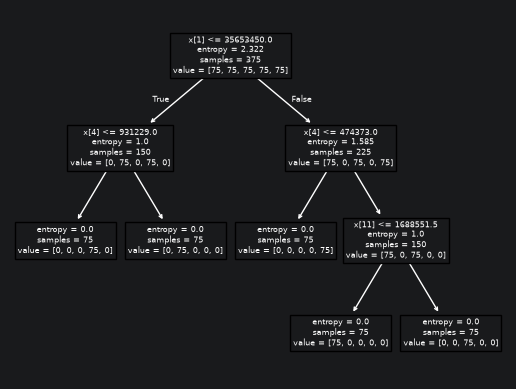

In [72]:
plot_tree(dt_bclasf)

## Train Random Forest

In [73]:
rf_clasf = RandomForestClassifier(random_state=42)
rf_gridsearch = GridSearchCV(
    rf_clasf,
    param_grid = {
        'n_estimators' : [5,10,25,50,100],
        'criterion' : ['entropy','gini'],
        'max_features' : [0.2,'sqrt',1.],
        'max_depth' : [2,4],
        'class_weight' : ['balanced'],
    },
    verbose=0,
    refit=True,
    cv=kfold,
    scoring='f1_weighted'
)
rf_gridsearch.fit(X_train,y_train)

rf_bclasf = rf_gridsearch.best_estimator_
rf_bclasf.fit(X_train,y_train)

rf_y_pred = rf_bclasf.predict(X_test)
print("Random Forest: \n",
    "Accuracy:", accuracy_score(y_test, rf_y_pred), "\n",
    "F1-Score:", f1_score(y_test,rf_y_pred, average='weighted'), "\n",
    "Oil Trade Prediction:", rf_bclasf.predict([graph_embedding])
)

Random Forest: 
 Accuracy: 1.0 
 F1-Score: 1.0 
 Oil Trade Prediction: [2.]


In [85]:
rf_predictions = rf_bclasf.predict_proba([graph_embedding])
rf_predictions

array([[0.        , 0.81476846, 0.09503546, 0.        , 0.09019608]])

In [75]:
rf_bclasf.feature_importances_

array([0.        , 0.        , 0.14513648, 0.05334537, 0.        ,
       0.10156735, 0.20054799, 0.04335763, 0.04508729, 0.09820364,
       0.09908481, 0.10146087, 0.        , 0.0569199 , 0.05528868])

## Adaboost

In [76]:
ada_clasf = AdaBoostClassifier(random_state=42)
ada_gridsearch = GridSearchCV(
    ada_clasf,
    param_grid = {
        'n_estimators' : [5,10,25,50,100],
        'learning_rate' : [0.1,0.3,0.5]
        },
    verbose=0,
    refit=True,
    cv=kfold,
    scoring='f1_weighted',
)
ada_gridsearch.fit(X_train,y_train)

ada_bclasf = ada_gridsearch.best_estimator_
ada_bclasf.fit(X_train,y_train)

ada_y_pred = ada_bclasf.predict(X_test)
print("Adaboost: \n",
    "Accuracy:", accuracy_score(y_test, ada_y_pred), "\n",
    "F1-Score:", f1_score(y_test,ada_y_pred, average='weighted'), "\n",
    "Oil Trade Prediction:", ada_bclasf.predict([graph_embedding])
)


Adaboost: 
 Accuracy: 0.6 
 F1-Score: 0.5 
 Oil Trade Prediction: [2.]


In [77]:
ada_bclasf.feature_importances_

array([0.09614604, 0.        , 0.        , 0.20263369, 0.        ,
       0.31154643, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.17860959, 0.11187863, 0.09918562])

In [78]:
# Adaboost predictions need calibration, can use CalibratedClassifierCV from sklearn
# See paper: https://www.cs.cornell.edu/~caruana/niculescu.scldbst.crc.rev4.pdf for more details
# ada_bclasf.predict_proba([graph_embedding])

calibrated_clf = CalibratedClassifierCV(ada_gridsearch.best_estimator_, method='sigmoid')
calibrated_clf.fit(X_train,y_train)

ada_predictions = calibrated_clf.predict_proba([graph_embedding])

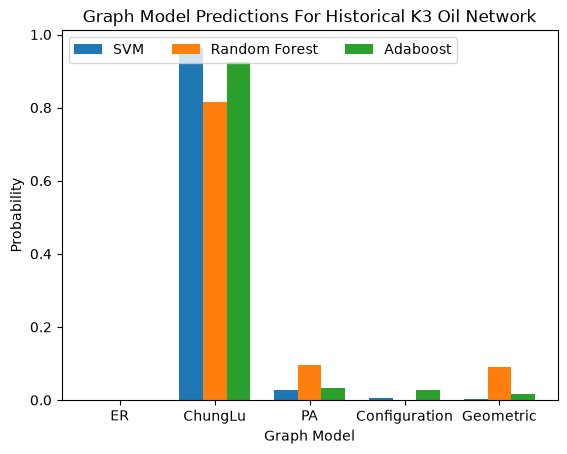

In [82]:
names = ['ER', 'ChungLu', 'PA', 'Configuration','Geometric']
predictions = {
    'SVM': svc_predictions[0],
    'Random Forest': rf_predictions[0],
    'Adaboost': ada_predictions[0]
}
plt.grouped_bar(predictions,tick_labels=names,group_spacing=1)
plt.ylabel('Probability')
plt.xlabel('Graph Model')
plt.title('Graph Model Predictions For Historical K3 Oil Network')
plt.legend(loc='upper left', ncols=3)
plt.style.use('ggplot')
plt.savefig('graph_model_historic.png', transparent=True)
plt.show()

## ChungLu Prediction % Over Time